In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [60]:
import os
from pathlib import Path
current_dir = Path(os.getcwd()).resolve()
project_root = current_dir.parent

In [61]:
file_str = project_root/'results/analysis/p_lambda_regimes_tau1e-06.csv'
print(file_str
)#p_lambda_regimes_tau1e-06.csv

/Users/minglu/Documents/Uni/bistable_model_simulation/results/analysis/p_lambda_regimes_tau1e-06.csv


In [62]:
df = pd.read_csv(file_str)

In [63]:
df.head()

,Unnamed: 0,gamma,timestep,macro_full,micro_full,diffusions,P_needed_1,P_needed_2_plus,P_needed_2_minus
0,0,0.200000,0.000001,[ 1.5 1500. 150. 25. 5.75 25. ],[7.26603271e+02 1.50000000e+03 1.84824440e+05 ...,100.000000,0.000722,0.044024,0.007337
1,1,0.296552,0.000001,[ 1.5 1500. 150. 25. 5.75 25. ],[7.20893578e+02 1.50000000e+03 5.75222408e+04 ...,219.857313,0.000719,0.039565,0.006594
2,2,0.393103,0.000001,[ 1.5 1500. 150. 25. 5.75 25. ],[7.18862479e+02 1.50000000e+03 4.56523056e+04 ...,386.325803,0.000717,0.038268,0.006378
3,3,0.489655,0.000001,[ 1.5 1500. 150. 25. 5.75 25. ],[7.17912785e+02 1.50000000e+03 4.15975219e+04 ...,599.405470,0.000716,0.037573,0.006262
4,4,0.586207,0.000001,[ 1.5 1500. 150. 25. 5.75 25. ],[7.17393349e+02 1.50000000e+03 3.96625861e+04 ...,859.096314,0.000716,0.037150,0.006192


In [64]:
gamma=np.array(df.gamma)
tau = np.array(df.timestep)
d = np.array(df.diffusions)
p1_n =np.array(df.P_needed_1)
p2p_n =np.array(df.P_needed_2_plus)
p2m_n =np.array(df.P_needed_2_minus)

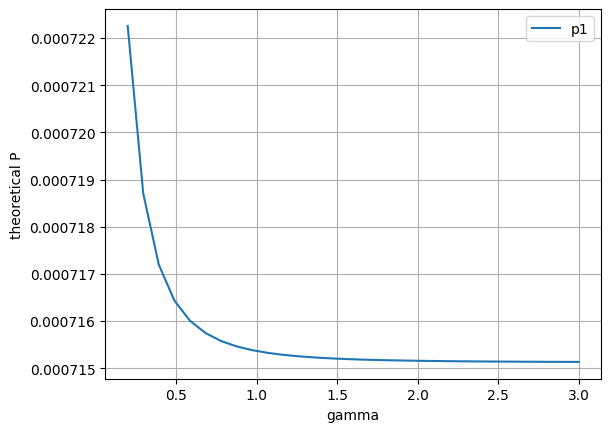

In [65]:
plt.plot(gamma, p1_n,label='p1')

#plt.plot(gamma, p2p_n,label='p2p')
#plt.plot(gamma, p2m_n,label='p2m')

# plt.ylim(0.0,0.002)
plt.xlabel('gamma')
plt.ylabel('theoretical P')
plt.legend()
plt.grid()


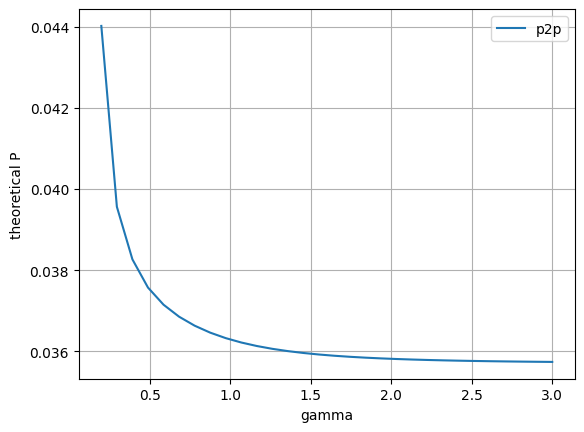

In [66]:
#plt.plot(gamma, p1_n,label='p1')
plt.plot(gamma, p2p_n,label='p2p')

plt.xlabel('gamma')
plt.ylabel('theoretical P')

plt.legend()
plt.grid()

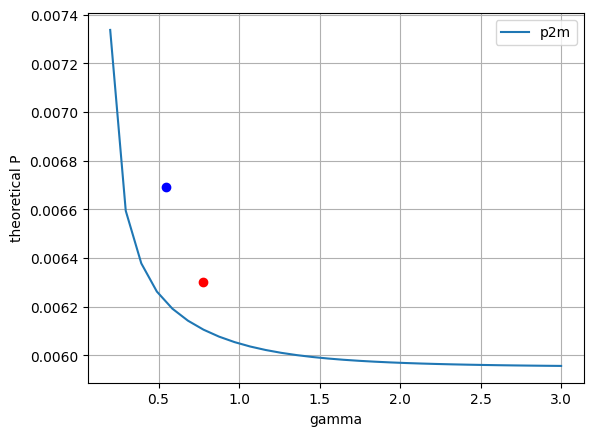

In [67]:
#plt.plot(gamma, p1_n,label='p1')
#plt.plot(gamma, p2p_n,label='p2p')
plt.plot(gamma, p2m_n,label='p2m')
plt.plot([0.7746], [0.00630019,], 'ro')
plt.plot([0.5477], [0.00669286,], 'bo')
plt.xlabel('gamma')
plt.ylabel('theoretical P')

plt.legend()
plt.grid()

In [68]:
print(p1_n)

[0.00072226 0.00071871 0.0007172  0.00071644 0.00071601 0.00071575
 0.00071558 0.00071546 0.00071538 0.00071533 0.00071528 0.00071525
 0.00071523 0.00071521 0.0007152  0.00071518 0.00071517 0.00071517
 0.00071516 0.00071516 0.00071515 0.00071515 0.00071515 0.00071514
 0.00071514 0.00071514 0.00071514 0.00071514 0.00071513 0.00071513]


In [69]:
print(p2p_n)
print(p2m_n)

[0.0440241  0.0395646  0.03826766 0.03757278 0.03715008 0.03685457
 0.03663307 0.03646129 0.03632578 0.03621788 0.03613142 0.03606176
 0.03600534 0.03595939 0.03592177 0.03589077 0.0358651  0.0358437
 0.03582576 0.03581063 0.03579782 0.0357869  0.03577754 0.03576949
 0.03576253 0.03575649 0.03575122 0.0357466  0.03574255 0.03573897]
[0.00733735 0.0065941  0.00637794 0.00626213 0.00619168 0.00614243
 0.00610551 0.00607688 0.0060543  0.00603631 0.0060219  0.00601029
 0.00600089 0.00599323 0.00598696 0.0059818  0.00597752 0.00597395
 0.00597096 0.00596844 0.0059663  0.00596448 0.00596292 0.00596158
 0.00596042 0.00595942 0.00595854 0.00595777 0.00595709 0.00595649]


In [70]:
import sys
# This finds the project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# --- THIS IS THE LINE YOU ARE MISSING ---
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
# --- ADD THAT LINE! ---

print(f"Project root added to path: {PROJECT_ROOT}")

Project root added to path: /Users/minglu/Documents/Uni/bistable_model_simulation


In [71]:
from simulation.solvers.rate_conversions import calculate_kappas

In [72]:
kappas = np.zeros((len(d),6))

In [73]:
for i in range(len(d)):
    dif=d[i]
    kappas[i]=calculate_kappas(np.array((1.5,1500,150,25,5.75,25)),dif,dif,dif,np.ones(4)*0.1)

✅ R1 Solver converged.
✅ R2 Solver converged and passed physics checks.

--- Final Intrinsic Rates (Kappa) ---
κ₁⁺ = 7.2660e+02
κ₁⁻ = 1.5000e+03
κ₂⁺ = 1.8482e+05
κ₂⁻ = 3.0804e+04
κ₃⁺ = 5.7500e+00
κ₃⁻ = 2.5000e+01
The estimation is calculated based on the Eq. (32) in Erban's paper.
✅ R1 Solver converged.
✅ R2 Solver converged and passed physics checks.

--- Final Intrinsic Rates (Kappa) ---
κ₁⁺ = 7.2089e+02
κ₁⁻ = 1.5000e+03
κ₂⁺ = 5.7522e+04
κ₂⁻ = 9.5870e+03
κ₃⁺ = 5.7500e+00
κ₃⁻ = 2.5000e+01
The estimation is calculated based on the Eq. (32) in Erban's paper.
✅ R1 Solver converged.
✅ R2 Solver converged and passed physics checks.

--- Final Intrinsic Rates (Kappa) ---
κ₁⁺ = 7.1886e+02
κ₁⁻ = 1.5000e+03
κ₂⁺ = 4.5652e+04
κ₂⁻ = 7.6087e+03
κ₃⁺ = 5.7500e+00
κ₃⁻ = 2.5000e+01
The estimation is calculated based on the Eq. (32) in Erban's paper.
✅ R1 Solver converged.
✅ R2 Solver converged and passed physics checks.

--- Final Intrinsic Rates (Kappa) ---
κ₁⁺ = 7.1791e+02
κ₁⁻ = 1.5000e+03
κ₂⁺ = 4.1

In [74]:
p_1_emp = 1-np.exp(-kappas[:,0]*tau[0])

p_2p_emp = 1-np.exp(-kappas[:,2]*tau[0])

p_2m_emp = 1-np.exp(-kappas[:,3]*tau[0])


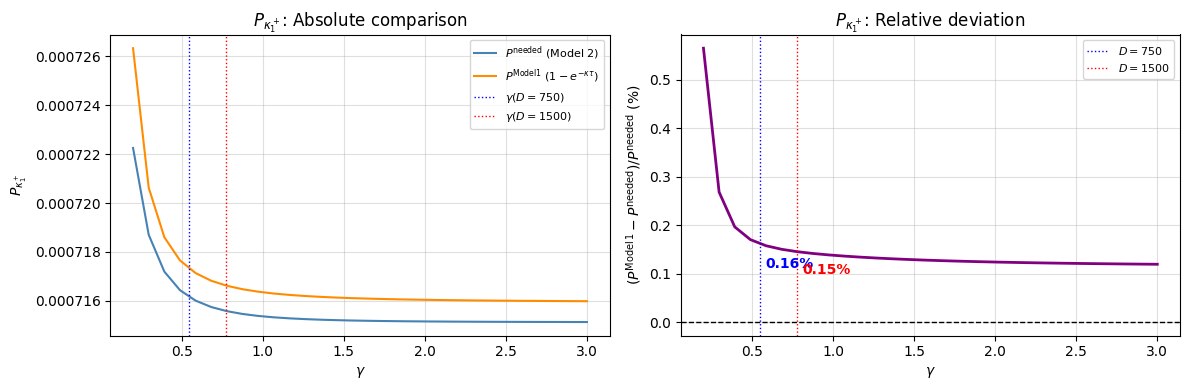

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: absolute comparison (what you have)
axes[0].plot(gamma, p1_n, label=r'$P^{\mathrm{needed}}$ (Model 2)', color='steelblue')
axes[0].plot(gamma, p_1_emp, label=r'$P^{\mathrm{Model 1}}$ ($1-e^{-\kappa\tau}$)', color='darkorange')
axes[0].axvline(0.5477, color='blue', lw=1, ls=':', label=r'$\gamma(D=750)$')
axes[0].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\gamma(D=1500)$')
axes[0].set_xlabel(r'$\gamma$')
axes[0].set_ylabel(r'$P_{\kappa_1^+}$')
axes[0].set_title(r'$P_{\kappa_1^+}$: Absolute comparison')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.4)

# Right panel: RELATIVE deviation — this makes the argument compelling!
rel_dev = (p_1_emp - p1_n) / p1_n * 100  # in %
axes[1].plot(gamma, rel_dev, color='purple', lw=2)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0.5477, color='blue', lw=1, ls=':', label=r'$D=750$')
axes[1].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$D=1500$')

# Annotate the actual % at your operating points
for gv, color, tau_str in [(0.5477, 'blue', r'$D=750$'), 
                            (0.7746, 'red',  r'$D=1500$')]:
    idx = np.argmin(np.abs(gamma - gv))
    pct = rel_dev[idx]
    axes[1].annotate(f'{pct:.2f}%', 
                     xy=(gv, pct), 
                     xytext=(4, -16),            # 10 points right, 15 points down
                     textcoords='offset points',  # Tells matplotlib to use points, not data units
                     color=color, 
                     fontsize=10, 
                     fontweight='bold')

axes[1].set_xlabel(r'$\gamma$')
axes[1].set_ylabel(r'$(P^{\mathrm{Model\,1}} - P^{\mathrm{needed}}) / P^{\mathrm{needed}}$ (%)')
axes[1].set_title(r'$P_{\kappa_1^+}$: Relative deviation')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4)

plt.tight_layout()

#plt.savefig('p_lambda_comparison.pdf')'

[ 2.83312290e+02  4.12856538e+01  1.66152221e+01  8.44077903e+00
  4.67359093e+00  2.66967464e+00  1.50617979e+00  7.86240809e-01
  3.16695073e-01 -4.26303536e-03 -2.33310238e-01 -4.03325650e-01
 -5.34045324e-01 -6.37685926e-01 -7.22034355e-01 -7.92198688e-01
 -8.51626493e-01 -9.02710862e-01 -9.47158956e-01 -9.86220878e-01
 -1.02083479e+00 -1.05172083e+00 -1.07944322e+00 -1.10445217e+00
 -1.12711271e+00 -1.14772504e+00 -1.16653907e+00 -1.18376506e+00
 -1.19958157e+00 -1.21414146e+00]


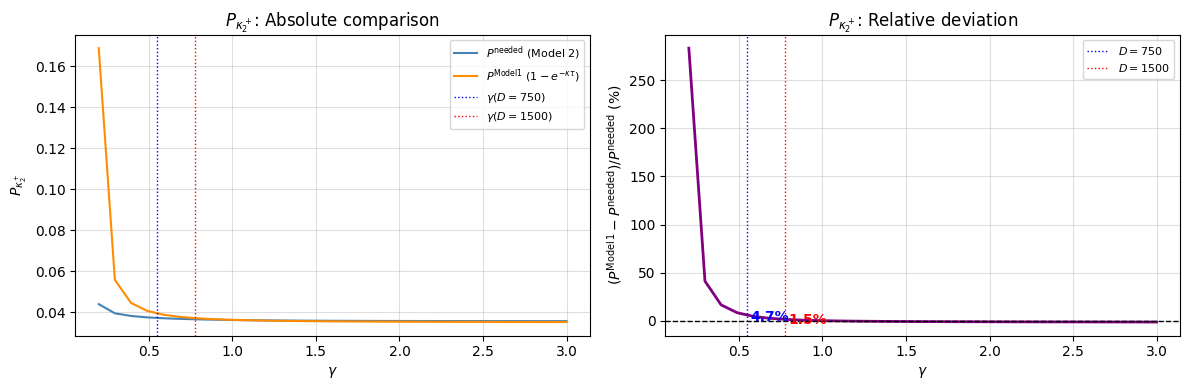

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: absolute comparison (what you have)
axes[0].plot(gamma, p2p_n, label=r'$P^{\mathrm{needed}}$ (Model 2)', color='steelblue')
axes[0].plot(gamma, p_2p_emp, label=r'$P^{\mathrm{Model 1}}$ ($1-e^{-\kappa\tau}$)', color='darkorange')
axes[0].axvline(0.5477, color='blue', lw=1, ls=':', label=r'$\gamma(D=750)$')
axes[0].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\gamma(D=1500)$')
axes[0].set_xlabel(r'$\gamma$')
axes[0].set_ylabel(r'$P_{\kappa_2^+}$')
axes[0].set_title(r'$P_{\kappa_2^+}$: Absolute comparison')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.4)

# Right panel: RELATIVE deviation — this makes the argument compelling!
rel_dev = (p_2p_emp - p2p_n) / p2p_n * 100  # in %
axes[1].plot(gamma, rel_dev, color='purple', lw=2)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0.5477, color='blue', lw=1, ls=':', label=r'$D=750$')
axes[1].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$D=1500$')

# Annotate the actual % at your operating points
for gv, color, tau_str in [(0.5477, 'blue', r'$\tau=10^{-6}$'), 
                            (0.7746, 'red',  r'$\tau=2\times10^{-6}$')]:
    idx = np.argmin(np.abs(gamma - gv))
    pct = rel_dev[idx]
    axes[1].annotate(f'{pct:.1f}%', xy=(gv, pct), 
                     xytext=(gv+0.02, pct-4.6),
                     color=color, fontsize=10, fontweight='bold')

axes[1].set_xlabel(r'$\gamma$')
axes[1].set_ylabel(r'$(P^{\mathrm{Model\,1}} - P^{\mathrm{needed}}) / P^{\mathrm{needed}}$ (%)')
axes[1].set_title(r'$P_{\kappa_2^+}$: Relative deviation')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4)

plt.tight_layout()
print(rel_dev)
#plt.savefig('p_lambda_comparison.pdf')

[3.13425291e+02 4.46934435e+01 1.88446507e+01 1.03289563e+01
 6.41102638e+00 4.32683075e+00 3.11559104e+00 2.36502856e+00
 1.87469229e+00 1.53896442e+00 1.29902503e+00 1.12072171e+00
 9.83527258e-01 8.74714323e-01 7.86155178e-01 7.12507404e-01
 6.50157935e-01 5.96593949e-01 5.50019764e-01 5.09118538e-01
 4.72900913e-01 4.40606838e-01 4.11640550e-01 3.85526605e-01
 3.61879520e-01 3.40382386e-01 3.20771501e-01 3.02825117e-01
 2.86355042e-01 2.71200288e-01]


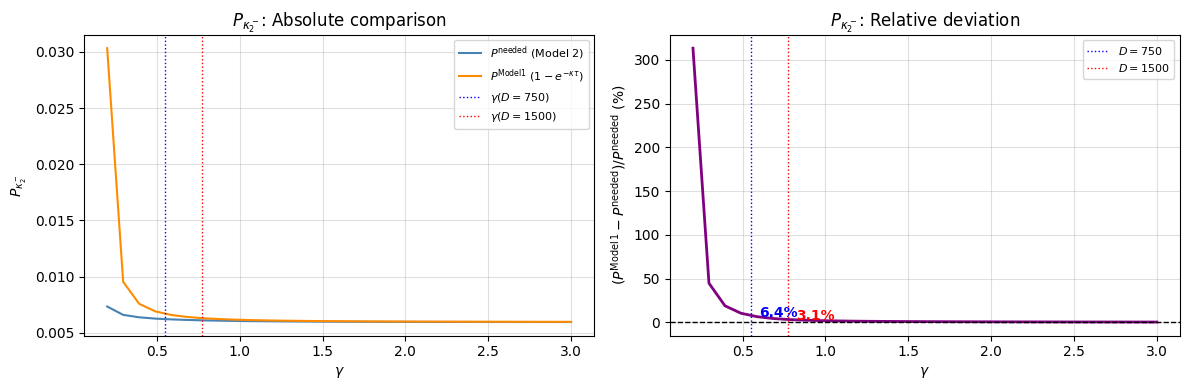

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: absolute comparison (what you have)
axes[0].plot(gamma, p2m_n, label=r'$P^{\mathrm{needed}}$ (Model 2)', color='steelblue')
axes[0].plot(gamma, p_2m_emp, label=r'$P^{\mathrm{Model 1}}$ ($1-e^{-\kappa\tau}$)', color='darkorange')
axes[0].axvline(0.5477, color='blue', lw=1, ls=':', label=r'$\gamma(D=750)$')
axes[0].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$\gamma(D=1500)$')
axes[0].set_xlabel(r'$\gamma$')
axes[0].set_ylabel(r'$P_{\kappa_2^-}$')
axes[0].set_title(r'$P_{\kappa_2^-}$: Absolute comparison')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.4)

# Right panel: RELATIVE deviation — this makes the argument compelling!
rel_dev = (p_2m_emp - p2m_n) / p2m_n * 100  # in %
axes[1].plot(gamma, rel_dev, color='purple', lw=2)
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].axvline(0.5477, color='blue', lw=1, ls=':', label=r'$D=750$')
axes[1].axvline(0.7746, color='red',  lw=1, ls=':', label=r'$D=1500$')

# Annotate the actual % at your operating points
for gv, color, tau_str in [(0.5477, 'blue', r'$D=750$'), 
                            (0.7746, 'red',  r'$D=1500$')]:
    idx = np.argmin(np.abs(gamma - gv))
    pct = rel_dev[idx]
    axes[1].annotate(f'{pct:.1f}%', xy=(gv, pct), 
                     xytext=(gv+0.05, pct),
                     color=color, fontsize=10, fontweight='bold')

axes[1].set_xlabel(r'$\gamma$')
axes[1].set_ylabel(r'$(P^{\mathrm{Model\,1}} - P^{\mathrm{needed}}) / P^{\mathrm{needed}}$ (%)')
axes[1].set_title(r'$P_{\kappa_2^-}$: Relative deviation')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4)

plt.tight_layout()
print(rel_dev)
#plt.savefig('p_lambda_comparison.pdf')

p1=1-exp(-kappa*tau)
kappa=-ln(1-p1)/tau

In [78]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, ax = plt.subplots(figsize=(8, 5))

# # Compute relative deviations (%)
# kappa_model1_vals = [717.57, 40292., 6715.4]  # your red line values
# labels   = [r'$\kappa_1^+$', r'$\kappa_2^+$', r'$\kappa_2^-$']
# colors   = ['steelblue', 'darkorange', 'seagreen']
# p_curves = [p1_n, p2p_n, p2m_n]

# for p_n, kappa_ref, label, color in zip(p_curves, kappa_model1_vals, labels, colors):
#     kappa_implied = -np.log(1 - p_n) / tau   # tau is your fixed tau
#     deviation = (kappa_implied - kappa_ref) / kappa_ref * 100
#     ax.plot(gamma, deviation, label=label, color=color, lw=2)

# ax.axhline(0, color='red', lw=1.5, linestyle='--', label='Model 1 target')
# ax.axvline(0.7746, color='gray', lw=1, linestyle=':', label=r'$\gamma$ at $\tau=10^{-6}$')
# ax.axvline(0.5477, color='steelblue', lw=1, linestyle=':', label=r'$\gamma$ at $\tau=2\times10^{-6}$')

# ax.set_xlabel(r'$\gamma$', fontsize=13)
# ax.set_ylabel(r'Relative deviation of $\kappa_{\mathrm{implied}}$ from Model 1 (%)', fontsize=11)
# ax.set_title('Self-consistency between Model 1 and Model 2', fontsize=13)
# ax.legend()
# ax.grid(True, alpha=0.4)
# plt.tight_layout()
# plt.savefig('kappa_consistency.pdf', dpi=150)
# plt.show()

In [79]:
# fig, ax = plt.subplots(figsize=(7, 4))
# ratio = (-np.log(1 - p2p_n) / tau) / (-np.log(1 - p2m_n) / tau)

# ax.plot(gamma, ratio, color='purple', lw=2, label=r'$\kappa_2^+ / \kappa_2^-$')
# ax.axhline(6.0, color='red', linestyle='--', label='Target Ratio (6.0)')
# ax.axvline(0.7746, color='gray', linestyle=':', label=r'Your $\gamma$')

# ax.set_xlabel(r'$\gamma$', fontsize=13)
# ax.set_ylabel(r'Implied Microscopic Ratio', fontsize=12)
# ax.set_title('Thermodynamic Imbalance in Channel 2', fontsize=13)
# ax.legend()
# ax.grid(True, alpha=0.4)
# plt.tight_layout()
# plt.show()